<a href="https://colab.research.google.com/github/Qalani/Dissertation/blob/main/Rebuild_AOI_WH_TimeSeries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rebuild AOI-level water-hyacinth time series

This notebook reconstructs the AOI-level water-hyacinth (WH) time series directly from the **final classified GeoTIFFs** produced by `Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb`.

`classified_geotiffs/` accumulates the output of every classifier run and every batch-export schema ever written into it, so a plain directory scan quietly mixes superseded rasters into the series. This notebook therefore ingests **only the current version** of each classified raster:

- a raster must start with the **current batch-export prefix** for its sensor (`winam_s2_predictors_s2_whlev_temporal_v1_`, `winam_s1_scc_temporal_v1_`), so superseded schemas (`s2_whlev_texture_v1`, `winam_s1_scc_predictors_...`) are excluded — matched with `startswith`, so a file that merely mentions the token elsewhere in its name does not pass;
- when the run log of the active classifier version is on disk it is intersected with the folder scan, so rasters left behind by any other run are excluded;
- exactly one raster per sensor / product / acquisition survives: the S1 `*_patch_cleaned.tif` raster supersedes its raw input, and any other competition is reported rather than silently resolved;
- one model slug per sensor, so two classifier configurations never end up in the same series;
- probability rasters, pre-mosaic `*_tile_NNN.tif` shards and Google Drive `... (1).tif` collision copies are excluded;
- paper-rule rasters (`*_local_rules.tif`) are kept, labelled as their own product rather than mixed into the model series.

Other conventions match the classifier notebook: floating plants / WH class code **2**, classification nodata **255**, dates parsed from `YYYY-MM-DD_to_YYYY-MM-DD` in each filename.

For each selected raster it calculates WH area and the percentage of valid classified AOI occupied by WH, then saves a tidy CSV (carrying the provenance of every row) and a publication-ready PNG.

In [1]:
# Colab setup
import sys
import subprocess
import importlib.util

if importlib.util.find_spec("rasterio") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "rasterio"])

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass

from pathlib import Path
import re

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D


Mounted at /content/drive


## Configuration

`CLASSIFIED_DIR` is usually the only path you need to change.

The provenance block defines what *newest version* means here: one classifier run, and the current batch-export schema per sensor. Its values are copied from `Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb` and `Batch_Export.ipynb`, and are the same ones the spatial-panel notebooks pin.

In [2]:
CLASSIFIED_DIR = Path(
    "/content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/classified_geotiffs"
)

OUTPUT_DIR = CLASSIFIED_DIR.parent
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = TABLE_DIR / "winam_rebuilt_aoi_wh_timeseries.csv"
PNG_PATH = FIGURE_DIR / "winam_rebuilt_aoi_wh_timeseries.png"

# ---------------------------------------------------------------------
# Which version of the classified rasters to ingest
# ---------------------------------------------------------------------

# CLASSIFIER_VERSION from Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb
# ('route_b_s1_scc_spatialcv_proba_v4_whlev_temporal') plus the manual-correction
# suffix '_corr_' + MANUAL_CORRECTION_VERSION ('v1'). This is the same value the
# spatial-panel notebooks pin as ACTIVE_CLASSIFIER_VERSION, so the AOI series and
# the panel describe the same classifier run.
ACTIVE_CLASSIFIER_VERSION = "route_b_s1_scc_spatialcv_proba_v4_whlev_temporal_corr_v1"

# The run log that classifier run writes, addressed by its exact name. Never
# 'winam_full_stack_run_log_*.csv' wildcard and never by modification time:
# "newest file on disk" silently promotes a partial rerun of another version.
CLASSIFIER_RUN_LOG_PATH = (
    TABLE_DIR / f"winam_full_stack_run_log_{ACTIVE_CLASSIFIER_VERSION}.csv"
)

# How the run log is used:
#   "if_present" - intersect the folder scan with the run log when it exists, and
#                  fall back to the filename gate alone (loudly) when it does not.
#   "require"    - the run log must exist; a missing one is an error. Use this for
#                  the final dissertation figures.
#   "off"        - filename gate only.
RUN_LOG_MODE = "if_present"

# Run-log statuses that count as a finished classification. 'completed_prior_run'
# is a dataset a resumed batch reused instead of reclassifying, so its raster is
# just as much a product of this run as a freshly written one.
RUN_LOG_COMPLETED_STATUSES = ("completed", "completed_prior_run")

# S1_EXPORT_SCHEMA_VERSION / S2_EXPORT_SCHEMA_VERSION from Batch_Export.ipynb.
# The token identifies the PREDICTOR SCHEMA a snapshot was exported with, not the
# classifier that later consumed it, so it is tracked separately from the
# classifier version above.
REQUIRED_EXPORT_TOKEN_BY_SENSOR = {
    "S1": "s1_scc_temporal_v1",
    "S2": "s2_whlev_temporal_v1",
}

# Section 7 of Batch_Export.ipynb builds each snapshot prefix as
#   S1: f"winam_{S1_EXPORT_SCHEMA_VERSION}_{start}_to_{end}"
#   S2: f"winam_s2_predictors_{S2_EXPORT_SCHEMA_VERSION}_{start}_to_{end}"
# so a classified raster from the current schema starts with exactly these.
REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR = {
    "S1": "winam_s1_scc_temporal_v1_",
    "S2": "winam_s2_predictors_s2_whlev_temporal_v1_",
}

# Model-raster slug ('winam_..._local_<slug>.tif') to keep per sensor. None infers
# it from whatever survives selection and raises if more than one slug is left,
# because two slugs in one series means two different classifier configurations.
MODEL_SLUG_BY_SENSOR = {"S1": None, "S2": None}

# Keep the paper-rule rasters as a second, separately labelled product.
INCLUDE_RULE_RASTERS = True

# '<model raster>_patch_cleaned.tif' is the final S1 product and supersedes the
# raw model raster it was filtered from.
PREFER_PATCH_CLEANED_S1 = True

# Matches Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb
FLOATING_CLASS_CODE = 2
NODATA_VALUE = 255

# Figure controls
PLOT_SENSOR = "S2"          # "S2", "S1", or None
PLOT_KIND = "model"         # "model", "rules", or None
ROLLING_MEDIAN_POINTS = 5   # 0 or 1 disables smoothing

# The series is built from single-date snapshots, so some calendar months
# carry several acquisitions and some carry none. True draws the line dashed
# across the months that carry none, so a stretch the record never measured
# cannot read as a measured trend. False draws one solid line throughout.
DASH_UNOBSERVED_MONTHS = True

print("Classified raster folder:", CLASSIFIED_DIR)
print("Classifier run          :", ACTIVE_CLASSIFIER_VERSION)
print("Run log                 :", CLASSIFIER_RUN_LOG_PATH)
print("Run-log mode            :", RUN_LOG_MODE)
print("CSV output              :", CSV_PATH)
print("Figure output           :", PNG_PATH)

Classified raster folder: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/classified_geotiffs
Classifier run          : route_b_s1_scc_spatialcv_proba_v4_whlev_temporal_corr_v1
Run log                 : /content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/tables/winam_full_stack_run_log_route_b_s1_scc_spatialcv_proba_v4_whlev_temporal_corr_v1.csv
Run-log mode            : if_present
CSV output              : /content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/tables/winam_rebuilt_aoi_wh_timeseries.csv
Figure output           : /content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/figures/winam_rebuilt_aoi_wh_timeseries.png


## Select the current classified rasters

The folder is filtered on provenance before a single pixel is read: current export prefix, final classification products only, one model slug per sensor, and one raster per sensor / product / acquisition. When the active run log is available, membership of that run is also required.

Every rejected file is counted by reason in `SELECTION_AUDIT` and printed below, so nothing is dropped silently. Competing rasters that have no defined winner raise instead of being resolved by chance.

In [3]:
DATE_RE = re.compile(
    r"(?P<start>\d{4}-\d{2}-\d{2})_to_(?P<end>\d{4}-\d{2}-\d{2})"
)

_PROBABILITY_SUFFIX = "_proba"
_RULE_SUFFIX = "_local_rules"
_PATCH_CLEANED_SUFFIX = "_patch_cleaned"
_MODEL_SEGMENT = "_local_"
_TILE_INTERMEDIATE_RE = re.compile(r"_tile_\d+$")
# Google Drive's collision marker, e.g. "foo (1).tif": a stale re-download of an
# earlier file, not a product of the current run.
_DRIVE_COLLISION_RE = re.compile(r"\s\(\d+\)$")
_GEOTIFF_SUFFIXES = {".tif", ".tiff"}

# Populated by select_classified_rasters().
SELECTION_AUDIT = {}


def blank_value(value):
    """True for the several ways a run-log cell can be empty."""
    if value is None:
        return True
    if isinstance(value, float) and pd.isna(value):
        return True
    return str(value).strip() in {"", "nan", "None"}


def normalise_sensor(sensor):
    if blank_value(sensor):
        return None
    sensor = str(sensor).strip().upper()
    if sensor in {"S1", "S1_SCC", "SCC"}:
        return "S1"
    if sensor == "S2":
        return "S2"
    return sensor


def check_prefix_token_consistency():
    """Fail fast if a required prefix does not carry its sensor's export token.

    Batch_Export.ipynb builds every snapshot prefix around the schema token, so
    the two settings must agree. Checking it here lets the token be read back out
    of the prefix rather than searched for anywhere in a filename.
    """
    for sensor, prefix in REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR.items():
        token = REQUIRED_EXPORT_TOKEN_BY_SENSOR.get(sensor)
        if token is None:
            raise ValueError(
                f"REQUIRED_EXPORT_TOKEN_BY_SENSOR has no entry for sensor {sensor!r}, "
                f"but REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR does ({prefix!r})."
            )
        if f"_{token}_" not in f"_{prefix}":
            raise ValueError(
                f"Configuration mismatch for {sensor}: required export token {token!r} is "
                f"not a token of the required prefix {prefix!r}. Check "
                "S1_EXPORT_SCHEMA_VERSION / S2_EXPORT_SCHEMA_VERSION and the section 7 "
                "prefixes in Batch_Export.ipynb."
            )


def sensor_from_path(path):
    """Sensor implied by an EXACT prefix match, or None.

    startswith() against the configured prefixes only. A substring search would
    let a re-export that merely mentions 's1_scc_temporal_v1' somewhere in its
    name claim to be a current S1 product.
    """
    name = Path(path).name
    for sensor, prefix in REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR.items():
        if name.startswith(prefix):
            return sensor
    return None


def product_from_path(path):
    """'model', 'rules', 'probability', 'tile_intermediate' or 'unknown'.

    Only 'model' and 'rules' are final classifications. A probability surface, a
    pre-mosaic tile or an unrecognised diagnostic must never reach the area
    calculation, where every non-nodata pixel would be counted as a class.
    """
    stem = Path(path).stem
    if _TILE_INTERMEDIATE_RE.search(stem):
        return "tile_intermediate"
    base = stem[: -len(_PATCH_CLEANED_SUFFIX)] if stem.endswith(_PATCH_CLEANED_SUFFIX) else stem
    if base.endswith(_PROBABILITY_SUFFIX):
        return "probability"
    if base.endswith(_RULE_SUFFIX):
        return "rules"
    if _MODEL_SEGMENT in base:
        return "model"
    return "unknown"


def model_slug_from_path(path):
    """The '<slug>' of 'winam_..._local_<slug>.tif', ignoring the patch suffix."""
    stem = Path(path).stem
    if stem.endswith(_PATCH_CLEANED_SUFFIX):
        stem = stem[: -len(_PATCH_CLEANED_SUFFIX)]
    if _MODEL_SEGMENT not in stem:
        return None
    return stem.split(_MODEL_SEGMENT, 1)[1]


def patch_clean_base_stem(path):
    """Stem with the S1 patch-filter suffix removed, so raw and cleaned pair up."""
    stem = Path(path).stem
    if stem.endswith(_PATCH_CLEANED_SUFFIX):
        return stem[: -len(_PATCH_CLEANED_SUFFIX)]
    return stem


def describe_classified_raster(path):
    """(record, None) for a current classified raster, or (None, reason)."""
    path = Path(path)
    stem = path.stem

    if path.suffix.lower() not in _GEOTIFF_SUFFIXES:
        return None, "not_a_geotiff"
    if _DRIVE_COLLISION_RE.search(stem):
        return None, "drive_collision_copy"

    sensor = sensor_from_path(path)
    if sensor is None:
        return None, "prefix_is_not_the_current_export_schema"

    product = product_from_path(path)
    if product == "model":
        kind = "model"
    elif product == "rules":
        if not INCLUDE_RULE_RASTERS:
            return None, "rule_raster_excluded_by_INCLUDE_RULE_RASTERS"
        kind = "rules"
    else:
        return None, f"not_a_final_classification_{product}"

    match = DATE_RE.search(stem)
    if not match:
        return None, "no_date_window_in_filename"

    slug = model_slug_from_path(path) if kind == "model" else None
    if kind == "model":
        method = f"Route_B_{slug}" if sensor == "S2" else f"Route_B_SCC_{slug}"
    else:
        method = "Paper_rules" if sensor == "S2" else "Paper_rules_SCC"

    return {
        "path": str(path),
        "file_name": path.name,
        "sensor": sensor,
        "kind": kind,
        "method": method,
        "model_slug": "" if slug is None else slug,
        "start_date": match.group("start"),
        "end_date": match.group("end"),
        "patch_cleaned": stem.endswith(_PATCH_CLEANED_SUFFIX),
        "export_token": REQUIRED_EXPORT_TOKEN_BY_SENSOR[sensor],
        "classifier_version": ACTIVE_CLASSIFIER_VERSION,
    }, None


def read_active_run_log():
    """(path, dataframe) for the active classifier run, or (None, None).

    The log is addressed by the exact name of ACTIVE_CLASSIFIER_VERSION. A run log
    belonging to any other version is not a substitute for it, so it is never
    picked up by wildcard or by being the most recently modified file.
    """
    if RUN_LOG_MODE not in {"require", "if_present", "off"}:
        raise ValueError(
            "RUN_LOG_MODE must be 'require', 'if_present' or 'off' "
            f"(got {RUN_LOG_MODE!r})."
        )
    if RUN_LOG_MODE == "off":
        return None, None

    path = Path(CLASSIFIER_RUN_LOG_PATH)
    expected_name = f"winam_full_stack_run_log_{ACTIVE_CLASSIFIER_VERSION}.csv"
    if path.name != expected_name:
        raise ValueError(
            "CLASSIFIER_RUN_LOG_PATH must name the active classifier run.\n"
            f"  ACTIVE_CLASSIFIER_VERSION : {ACTIVE_CLASSIFIER_VERSION}\n"
            f"  expected filename         : {expected_name}\n"
            f"  configured filename       : {path.name}"
        )

    if not path.exists():
        if RUN_LOG_MODE == "require":
            raise FileNotFoundError(
                "The run log of the active classifier run was not found:\n"
                f"  {path}\n"
                f"  ACTIVE_CLASSIFIER_VERSION = {ACTIVE_CLASSIFIER_VERSION!r}\n"
                "Run Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb for this exact "
                "version, correct ACTIVE_CLASSIFIER_VERSION, or set "
                "RUN_LOG_MODE = 'if_present' to fall back to the filename gate."
            )
        print(
            "WARNING: no run log for the active classifier run at\n"
            f"  {path}\n"
            "Falling back to the filename gate alone. Rasters carrying the current export "
            "prefix but written by an EARLIER classifier run cannot be told apart from "
            "current ones this way. Set RUN_LOG_MODE = 'require' for the final figures."
        )
        return None, None

    log = pd.read_csv(path)
    required = {"sensor", "status", "prefix", "model_classification_tif"}
    missing = required.difference(log.columns)
    if missing:
        raise ValueError(
            f"Classifier run log is missing required columns {sorted(missing)}: {path}"
        )
    return path, log.reset_index(drop=True)


def _run_log_completed_rows(log):
    statuses = {str(s).strip().lower() for s in RUN_LOG_COMPLETED_STATUSES}
    for _, row in log.iterrows():
        if str(row.get("status", "")).strip().lower() in statuses:
            yield row


def run_log_current_file_names(log):
    """File names the active run log accounts for as finished classifications."""
    names = set()
    for row in _run_log_completed_rows(log):
        for column in ("model_classification_tif", "rule_classification_tif"):
            value = row.get(column, "")
            if blank_value(value):
                continue
            name = Path(str(value).strip()).name
            names.add(name)
            if column != "model_classification_tif":
                continue
            # The S1 patch filter writes '<model raster>_patch_cleaned.tif' beside
            # its input, so either side of that pair belongs to this run whichever
            # one the log happened to record.
            stem, suffix = Path(name).stem, Path(name).suffix
            if stem.endswith(_PATCH_CLEANED_SUFFIX):
                names.add(f"{stem[: -len(_PATCH_CLEANED_SUFFIX)]}{suffix}")
            else:
                names.add(f"{stem}{_PATCH_CLEANED_SUFFIX}{suffix}")

        # A dataset a resumed batch reused ('completed_prior_run') records no rule
        # raster, so derive its deterministic name from the snapshot prefix rather
        # than dropping the rules series for those dates.
        prefix = row.get("prefix", "")
        if not blank_value(prefix):
            names.add(f"{str(prefix).strip()}{_RULE_SUFFIX}.tif")
    return names


def run_log_files_missing_from_folder(log, folder):
    """Classifications the run log records but the folder does not hold."""
    folder = Path(folder)
    missing = set()
    for row in _run_log_completed_rows(log):
        for column in ("model_classification_tif", "rule_classification_tif"):
            value = row.get(column, "")
            if blank_value(value):
                continue
            name = Path(str(value).strip()).name
            if not (folder / name).exists():
                missing.add(name)
    return sorted(missing)


def apply_model_slug_filter(records, excluded):
    """Keep one model slug per sensor: pinned, or inferred when unambiguous."""
    kept = []
    slugs_by_sensor = {}

    for record in records:
        if record["kind"] != "model":
            kept.append(record)
            continue
        wanted = MODEL_SLUG_BY_SENSOR.get(record["sensor"])
        if wanted is not None and record["model_slug"] != wanted:
            excluded.append({
                "file_name": record["file_name"],
                "reason": f"model_slug_is_not_the_selected_{wanted}",
            })
            continue
        slugs_by_sensor.setdefault(record["sensor"], set()).add(record["model_slug"])
        kept.append(record)

    ambiguous = {s: sorted(v) for s, v in slugs_by_sensor.items() if len(v) > 1}
    if ambiguous:
        listing = "\n".join(
            f"  {sensor}: {', '.join(slugs)}" for sensor, slugs in sorted(ambiguous.items())
        )
        raise ValueError(
            "More than one model slug survived selection, so the series would mix two "
            "classifier configurations:\n" + listing +
            "\n\nPin the current slug per sensor in MODEL_SLUG_BY_SENSOR (configuration "
            "cell), or remove the superseded rasters, and re-run."
        )

    return kept, {s: sorted(v)[0] for s, v in slugs_by_sensor.items()}


def resolve_canonical_rasters(records):
    """Reduce to ONE raster per sensor, product and acquisition.

    An acquisition is the (sensor, kind, start_date, end_date) export window. The
    only competition with a defined winner is the S1 patch filter, whose cleaned
    raster supersedes its raw input; anything else is ambiguous and raises rather
    than being resolved by sort order.
    """
    grouped = {}
    for record in records:
        key = (record["sensor"], record["kind"], record["start_date"], record["end_date"])
        grouped.setdefault(key, {})[record["path"]] = record

    kept = []
    superseded = []
    ambiguous = []

    for key, by_path in sorted(grouped.items()):
        group = list(by_path.values())
        if len(group) == 1:
            kept.append(group[0])
            continue

        bases = {patch_clean_base_stem(r["path"]) for r in group}
        cleaned = [r for r in group if r["patch_cleaned"]]
        raw = [r for r in group if not r["patch_cleaned"]]

        if len(bases) > 1 or len(cleaned) > 1 or len(raw) > 1:
            ambiguous.append((key, group))
            continue

        if PREFER_PATCH_CLEANED_S1 and cleaned:
            chosen, dropped = cleaned[0], raw
            reason = "superseded_by_patch_cleaned_raster"
        elif raw:
            chosen, dropped = raw[0], cleaned
            reason = "patch_cleaned_raster_disabled_by_PREFER_PATCH_CLEANED_S1"
        else:
            chosen, dropped = cleaned[0], []
            reason = "superseded_by_patch_cleaned_raster"

        kept.append(chosen)
        superseded.extend(
            {"file_name": r["file_name"], "reason": reason} for r in dropped
        )

    if ambiguous:
        lines = []
        for (sensor, kind, start_date, end_date), group in ambiguous:
            lines.append(f"  {sensor} {kind} {start_date} to {end_date}:")
            lines.extend(
                f"    - {r['file_name']}" for r in sorted(group, key=lambda r: r["file_name"])
            )
        raise ValueError(
            "Competing classified rasters remain for the same sensor, product and "
            "acquisition, so the current raster is ambiguous:\n" + "\n".join(lines) +
            "\n\nOnly a raw/patch-cleaned S1 pair resolves automatically. Remove the "
            "superseded files, or re-run the classifier, before rebuilding the series."
        )

    return kept, superseded


def select_classified_rasters(folder):
    """Catalogue the current classified rasters in `folder`.

    Populates SELECTION_AUDIT with the provenance of the selection and the reason
    every rejected file was rejected.
    """
    global SELECTION_AUDIT

    check_prefix_token_consistency()

    folder = Path(folder)
    if not folder.exists():
        raise FileNotFoundError(
            f"CLASSIFIED_DIR does not exist:\n{folder}\n"
            "Update CLASSIFIED_DIR in the configuration cell."
        )

    run_log_path, run_log = read_active_run_log()
    allowed_names = None if run_log is None else run_log_current_file_names(run_log)
    selection_mode = "filename_gate" if run_log is None else "run_log_intersection"

    records = []
    excluded = []
    n_scanned = 0

    for path in sorted(folder.iterdir()):
        if not path.is_file():
            continue
        n_scanned += 1

        record, reason = describe_classified_raster(path)
        if record is None:
            excluded.append({"file_name": path.name, "reason": reason})
            continue
        if allowed_names is not None and record["file_name"] not in allowed_names:
            excluded.append({
                "file_name": path.name,
                "reason": "not_listed_in_the_active_classifier_run_log",
            })
            continue

        record["selection_mode"] = selection_mode
        record["source_run_log"] = "" if run_log_path is None else str(run_log_path)
        records.append(record)

    records, model_slug_by_sensor = apply_model_slug_filter(records, excluded)
    records, superseded = resolve_canonical_rasters(records)
    excluded.extend(superseded)

    excluded_reasons = {}
    for item in excluded:
        excluded_reasons[item["reason"]] = excluded_reasons.get(item["reason"], 0) + 1

    missing_from_folder = (
        [] if run_log is None else run_log_files_missing_from_folder(run_log, folder)
    )

    if not records:
        raise RuntimeError(
            "No current classified GeoTIFFs were selected.\n"
            f"  folder          : {folder}\n"
            f"  classifier run  : {ACTIVE_CLASSIFIER_VERSION}\n"
            f"  run log         : {run_log_path if run_log_path is not None else '(not used)'}\n"
            f"  files scanned   : {n_scanned}\n"
            f"  rejected        : {excluded_reasons}\n"
            "Check CLASSIFIED_DIR, ACTIVE_CLASSIFIER_VERSION and "
            "REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR."
        )

    catalogue = (
        pd.DataFrame(records)
        .sort_values(["sensor", "kind", "method", "start_date", "end_date"])
        .reset_index(drop=True)
    )

    SELECTION_AUDIT = {
        "classified_dir": str(folder),
        "classifier_version": ACTIVE_CLASSIFIER_VERSION,
        "run_log": "" if run_log_path is None else str(run_log_path),
        "run_log_mode": RUN_LOG_MODE,
        "selection_mode": selection_mode,
        "required_classified_prefix_by_sensor": dict(REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR),
        "required_export_token_by_sensor": dict(REQUIRED_EXPORT_TOKEN_BY_SENSOR),
        "model_slug_by_sensor": model_slug_by_sensor,
        "n_files_scanned": n_scanned,
        "n_selected": len(catalogue),
        "n_selected_by_sensor_kind": {
            f"{sensor}:{kind}": int(n)
            for (sensor, kind), n in catalogue.groupby(["sensor", "kind"]).size().items()
        },
        "excluded_reasons": excluded_reasons,
        "excluded_examples": excluded[:10],
        "run_log_files_missing_from_folder": missing_from_folder,
    }
    return catalogue


catalogue = select_classified_rasters(CLASSIFIED_DIR)

print(
    f"Selected {SELECTION_AUDIT['n_selected']:,} current classified rasters "
    f"from {SELECTION_AUDIT['n_files_scanned']:,} files in the folder."
)
print("Selection mode      :", SELECTION_AUDIT["selection_mode"])
print("Classifier run      :", SELECTION_AUDIT["classifier_version"])
print("Model slug by sensor:", SELECTION_AUDIT["model_slug_by_sensor"])
print("Selected by product :", SELECTION_AUDIT["n_selected_by_sensor_kind"])

if SELECTION_AUDIT["excluded_reasons"]:
    print("\nRejected as not current (or not a final classification):")
    for reason, n in sorted(
        SELECTION_AUDIT["excluded_reasons"].items(), key=lambda kv: (-kv[1], kv[0])
    ):
        print(f"  {n:>6,}  {reason}")

if SELECTION_AUDIT["run_log_files_missing_from_folder"]:
    missing = SELECTION_AUDIT["run_log_files_missing_from_folder"]
    print(
        f"\nWARNING: {len(missing):,} raster(s) recorded as classified in the run log are "
        "missing from the folder, so those dates are absent from the series:"
    )
    for name in missing[:5]:
        print("  ", name)
    if len(missing) > 5:
        print(f"   ... and {len(missing) - 5:,} more")

display(catalogue.head())

Selected 744 current classified rasters from 10,350 files in the folder.
Selection mode      : run_log_intersection
Classifier run      : route_b_s1_scc_spatialcv_proba_v4_whlev_temporal_corr_v1
Model slug by sensor: {'S2': 'logistic_regression_baseline'}
Selected by product : {'S2:model': 372, 'S2:rules': 372}

Rejected as not current (or not a final classification):
   9,234  prefix_is_not_the_current_export_schema
     372  not_a_final_classification_probability


,path,file_name,sensor,kind,method,model_slug,start_date,end_date,patch_cleaned,export_token,classifier_version,selection_mode,source_run_log
0,/content/drive/MyDrive/Winam_RF_Training_Data/...,winam_s2_predictors_s2_whlev_temporal_v1_2017-...,S2,model,Route_B_logistic_regression_baseline,logistic_regression_baseline,2017-04-02,2017-04-03,False,s2_whlev_temporal_v1,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,run_log_intersection,/content/drive/MyDrive/Winam_RF_Training_Data/...
1,/content/drive/MyDrive/Winam_RF_Training_Data/...,winam_s2_predictors_s2_whlev_temporal_v1_2017-...,S2,model,Route_B_logistic_regression_baseline,logistic_regression_baseline,2017-05-22,2017-05-23,False,s2_whlev_temporal_v1,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,run_log_intersection,/content/drive/MyDrive/Winam_RF_Training_Data/...
2,/content/drive/MyDrive/Winam_RF_Training_Data/...,winam_s2_predictors_s2_whlev_temporal_v1_2017-...,S2,model,Route_B_logistic_regression_baseline,logistic_regression_baseline,2017-06-11,2017-06-12,False,s2_whlev_temporal_v1,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,run_log_intersection,/content/drive/MyDrive/Winam_RF_Training_Data/...
3,/content/drive/MyDrive/Winam_RF_Training_Data/...,winam_s2_predictors_s2_whlev_temporal_v1_2017-...,S2,model,Route_B_logistic_regression_baseline,logistic_regression_baseline,2017-10-04,2017-10-05,False,s2_whlev_temporal_v1,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,run_log_intersection,/content/drive/MyDrive/Winam_RF_Training_Data/...
4,/content/drive/MyDrive/Winam_RF_Training_Data/...,winam_s2_predictors_s2_whlev_temporal_v1_2018-...,S2,model,Route_B_logistic_regression_baseline,logistic_regression_baseline,2018-05-12,2018-05-13,False,s2_whlev_temporal_v1,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,run_log_intersection,/content/drive/MyDrive/Winam_RF_Training_Data/...


## Read the pixels

This reads only the rasters selected above. It does **not** rerun the classifier or require the original predictor rasters.

In [4]:
def wh_metrics_from_geotiff(path, floating_code=2, nodata=255):
    floating_pixels = 0
    valid_pixels = 0

    with rasterio.open(path) as src:
        pixel_area_m2 = abs(src.transform.a * src.transform.e)

        for _, window in src.block_windows(1):
            arr = src.read(1, window=window)
            valid = arr != nodata
            valid_pixels += int(valid.sum())
            floating_pixels += int(np.count_nonzero(arr[valid] == floating_code))

        crs = str(src.crs)
        resolution_x = abs(src.transform.a)
        resolution_y = abs(src.transform.e)

    wh_area_m2 = floating_pixels * pixel_area_m2
    valid_area_m2 = valid_pixels * pixel_area_m2

    return {
        "wh_pixel_count": floating_pixels,
        "valid_pixel_count": valid_pixels,
        "pixel_area_m2": pixel_area_m2,
        "wh_area_m2": wh_area_m2,
        "wh_area_ha": wh_area_m2 / 10_000,
        "wh_area_km2": wh_area_m2 / 1_000_000,
        "valid_area_ha": valid_area_m2 / 10_000,
        "wh_coverage_pct": 100 * floating_pixels / valid_pixels if valid_pixels else np.nan,
        "crs": crs,
        "resolution_x": resolution_x,
        "resolution_y": resolution_y,
    }


rows = []

for i, item in catalogue.iterrows():
    metrics = wh_metrics_from_geotiff(
        item["path"],
        floating_code=FLOATING_CLASS_CODE,
        nodata=NODATA_VALUE,
    )

    row = item.to_dict()
    row.update(metrics)
    rows.append(row)

    if (i + 1) % 25 == 0 or (i + 1) == len(catalogue):
        print(f"Processed {i + 1:,}/{len(catalogue):,} rasters")

wh_ts = pd.DataFrame(rows)

wh_ts["start_date"] = pd.to_datetime(wh_ts["start_date"])
wh_ts["end_date"] = pd.to_datetime(wh_ts["end_date"])
wh_ts["mid_date"] = (
    wh_ts["start_date"] +
    (wh_ts["end_date"] - wh_ts["start_date"]) / 2
)
wh_ts["year"] = wh_ts["mid_date"].dt.year
wh_ts["month"] = wh_ts["mid_date"].dt.month
wh_ts["year_month"] = wh_ts["mid_date"].dt.to_period("M").astype(str)

columns = [
    "sensor", "kind", "method", "model_slug",
    "start_date", "end_date", "mid_date", "year", "month", "year_month",
    "wh_pixel_count", "valid_pixel_count", "pixel_area_m2",
    "wh_area_m2", "wh_area_ha", "wh_area_km2",
    "valid_area_ha", "wh_coverage_pct",
    "crs", "resolution_x", "resolution_y",
    # Provenance travels with every row, so a CSV read back later still says which
    # classifier run and which export schema it describes.
    "patch_cleaned", "classifier_version", "export_token",
    "selection_mode", "source_run_log", "file_name", "path",
]

wh_ts = (
    wh_ts[columns]
    .sort_values(["sensor", "kind", "method", "mid_date"])
    .reset_index(drop=True)
)

wh_ts.to_csv(CSV_PATH, index=False)

print(f"\nSaved {len(wh_ts):,} rows to:\n{CSV_PATH}")
display(wh_ts.head(10))

Processed 25/744 rasters
Processed 50/744 rasters
Processed 75/744 rasters
Processed 100/744 rasters
Processed 125/744 rasters
Processed 150/744 rasters
Processed 175/744 rasters
Processed 200/744 rasters
Processed 225/744 rasters
Processed 250/744 rasters
Processed 275/744 rasters
Processed 300/744 rasters
Processed 325/744 rasters
Processed 350/744 rasters
Processed 375/744 rasters
Processed 400/744 rasters
Processed 425/744 rasters
Processed 450/744 rasters
Processed 475/744 rasters
Processed 500/744 rasters
Processed 525/744 rasters
Processed 550/744 rasters
Processed 575/744 rasters
Processed 600/744 rasters
Processed 625/744 rasters
Processed 650/744 rasters
Processed 675/744 rasters
Processed 700/744 rasters
Processed 725/744 rasters
Processed 744/744 rasters

Saved 744 rows to:
/content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/tables/winam_rebuilt_aoi_wh_timeseries.csv


,sensor,kind,method,model_slug,start_date,end_date,mid_date,year,month,year_month,...,crs,resolution_x,resolution_y,patch_cleaned,classifier_version,export_token,selection_mode,source_run_log,file_name,path
0,S2,model,Route_B_logistic_regression_baseline,logistic_regression_baseline,2017-04-02,2017-04-03,2017-04-02 12:00:00,2017,4,2017-04,...,EPSG:32736,10.0,10.0,False,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,run_log_intersection,/content/drive/MyDrive/Winam_RF_Training_Data/...,winam_s2_predictors_s2_whlev_temporal_v1_2017-...,/content/drive/MyDrive/Winam_RF_Training_Data/...
1,S2,model,Route_B_logistic_regression_baseline,logistic_regression_baseline,2017-05-22,2017-05-23,2017-05-22 12:00:00,2017,5,2017-05,...,EPSG:32736,10.0,10.0,False,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,run_log_intersection,/content/drive/MyDrive/Winam_RF_Training_Data/...,winam_s2_predictors_s2_whlev_temporal_v1_2017-...,/content/drive/MyDrive/Winam_RF_Training_Data/...
2,S2,model,Route_B_logistic_regression_baseline,logistic_regression_baseline,2017-06-11,2017-06-12,2017-06-11 12:00:00,2017,6,2017-06,...,EPSG:32736,10.0,10.0,False,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,run_log_intersection,/content/drive/MyDrive/Winam_RF_Training_Data/...,winam_s2_predictors_s2_whlev_temporal_v1_2017-...,/content/drive/MyDrive/Winam_RF_Training_Data/...
3,S2,model,Route_B_logistic_regression_baseline,logistic_regression_baseline,2017-10-04,2017-10-05,2017-10-04 12:00:00,2017,10,2017-10,...,EPSG:32736,10.0,10.0,False,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,run_log_intersection,/content/drive/MyDrive/Winam_RF_Training_Data/...,winam_s2_predictors_s2_whlev_temporal_v1_2017-...,/content/drive/MyDrive/Winam_RF_Training_Data/...
4,S2,model,Route_B_logistic_regression_baseline,logistic_regression_baseline,2018-05-12,2018-05-13,2018-05-12 12:00:00,2018,5,2018-05,...,EPSG:32736,10.0,10.0,False,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,run_log_intersection,/content/drive/MyDrive/Winam_RF_Training_Data/...,winam_s2_predictors_s2_whlev_temporal_v1_2018-...,/content/drive/MyDrive/Winam_RF_Training_Data/...
5,S2,model,Route_B_logistic_regression_baseline,logistic_regression_baseline,2018-12-23,2018-12-24,2018-12-23 12:00:00,2018,12,2018-12,...,EPSG:32736,10.0,10.0,False,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,run_log_intersection,/content/drive/MyDrive/Winam_RF_Training_Data/...,winam_s2_predictors_s2_whlev_temporal_v1_2018-...,/content/drive/MyDrive/Winam_RF_Training_Data/...
6,S2,model,Route_B_logistic_regression_baseline,logistic_regression_baseline,2018-12-28,2018-12-29,2018-12-28 12:00:00,2018,12,2018-12,...,EPSG:32736,10.0,10.0,False,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,run_log_intersection,/content/drive/MyDrive/Winam_RF_Training_Data/...,winam_s2_predictors_s2_whlev_temporal_v1_2018-...,/content/drive/MyDrive/Winam_RF_Training_Data/...
7,S2,model,Route_B_logistic_regression_baseline,logistic_regression_baseline,2019-01-02,2019-01-03,2019-01-02 12:00:00,2019,1,2019-01,...,EPSG:32736,10.0,10.0,False,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,run_log_intersection,/content/drive/MyDrive/Winam_RF_Training_Data/...,winam_s2_predictors_s2_whlev_temporal_v1_2019-...,/content/drive/MyDrive/Winam_RF_Training_Data/...
8,S2,model,Route_B_logistic_regression_baseline,logistic_regression_baseline,2019-01-07,2019-01-08,2019-01-07 12:00:00,2019,1,2019-01,...,EPSG:32736,10.0,10.0,False,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,run_log_intersection,/content/drive/MyDrive/Winam_RF_Training_Data/...,winam_s2_predictors_s2_whlev_temporal_v1_2019-...,/content/drive/MyDrive/Winam_RF_Training_Data/...
9,S2,model,Route_B_logistic_regression_baseline,logistic_regression_baseline,2019-01-12,2019-01-13,2019-01-12 12:00:00,2019,1,2

## Quick QA


In [5]:
duplicate_mask = wh_ts.duplicated(
    ["sensor", "kind", "method", "start_date", "end_date"],
    keep=False,
)
n_duplicates = int(duplicate_mask.sum())
print("Duplicate sensor/method/date rows:", n_duplicates)
if n_duplicates:
    display(
        wh_ts.loc[duplicate_mask, ["sensor", "kind", "method", "start_date", "end_date", "file_name"]]
    )

print("Date range:", wh_ts["mid_date"].min(), "to", wh_ts["mid_date"].max())

# The series must describe ONE classifier run and ONE export schema per sensor.
print("\nProvenance of the rebuilt series:")
print("  classifier version:", sorted(wh_ts["classifier_version"].unique()))
print("  selection mode    :", sorted(wh_ts["selection_mode"].unique()))
print("  export token      :", {
    sensor: sorted(group["export_token"].unique())
    for sensor, group in wh_ts.groupby("sensor")
})
print("  model slug        :", {
    sensor: sorted(group["model_slug"].unique())
    for sensor, group in wh_ts[wh_ts["kind"].eq("model")].groupby("sensor")
})

assert wh_ts["classifier_version"].nunique() == 1, "The series mixes classifier versions."
for sensor, group in wh_ts.groupby("sensor"):
    assert group["export_token"].nunique() == 1, (
        f"{sensor}: the series mixes batch-export schemas."
    )
    models = group[group["kind"].eq("model")]
    assert models["model_slug"].nunique() <= 1, (
        f"{sensor}: the series mixes model slugs."
    )

print("\nRows by sensor and method:")
display(
    wh_ts.groupby(["sensor", "kind", "method"], dropna=False)
         .size()
         .rename("n_dates")
         .reset_index()
)

print("\nWH area summary (ha):")
display(
    wh_ts.groupby(["sensor", "kind", "method"])["wh_area_ha"]
         .agg(["count", "min", "median", "mean", "max"])
         .round(2)
         .reset_index()
)

Duplicate sensor/method/date rows: 0
Date range: 2017-04-02 12:00:00 to 2026-07-14 12:00:00

Provenance of the rebuilt series:
  classifier version: ['route_b_s1_scc_spatialcv_proba_v4_whlev_temporal_corr_v1']
  selection mode    : ['run_log_intersection']
  export token      : {'S2': ['s2_whlev_temporal_v1']}
  model slug        : {'S2': ['logistic_regression_baseline']}

Rows by sensor and method:


,sensor,kind,method,n_dates
0,S2,model,Route_B_logistic_regression_baseline,372
1,S2,rules,Paper_rules,372



WH area summary (ha):


,sensor,kind,method,count,min,median,mean,max
0,S2,model,Route_B_logistic_regression_baseline,372,0.87,548.13,909.85,14443.17
1,S2,rules,Paper_rules,372,44.28,811.48,1176.36,13059.34


## Publication-ready time series

The default plot shows the **S2 model series**. The thin line shows individual classified dates and the thicker line is a centred five-observation rolling median used only as a visual aid.

Both lines are drawn **solid between observations that fall in the same or in adjacent calendar months, and dashed wherever at least one whole calendar month carries no observation**. The series comes from single-date snapshots rather than monthly composites, so its cadence is uneven: joining every pair of consecutive acquisitions with the same solid line draws the months that were never measured as confidently as the ones that were.

Nothing is resampled or interpolated. Points stay on the dates they were acquired, markers are drawn on acquisitions only, and a dashed segment simply joins the last observation before a gap to the first one after it — there is no measurement underneath it. Set `DASH_UNOBSERVED_MONTHS = False` in the configuration cell to go back to a single solid line.


In [6]:
# ---------------------------------------------------------------------
# Solid within observed months, dashed across months with no observation
# ---------------------------------------------------------------------
# These helpers change only how the space BETWEEN two observations is drawn.
# Observations keep their acquisition dates: nothing is resampled onto a
# monthly grid, nothing is interpolated, and no marker is ever drawn where
# there was no classified raster.


def month_ordinal(dates):
    """Calendar months as running integers, so adjacent months differ by 1."""
    index = pd.DatetimeIndex(pd.to_datetime(pd.Series(dates).to_numpy()))
    return index.year.to_numpy(dtype="int64") * 12 + index.month.to_numpy(dtype="int64")


def observation_arrays(dates, values):
    """Date-sorted (date, value) pairs as plain arrays, ready to plot.

    Call sites pass filtered groups, so the row index is not 0..n-1, and a
    centred rolling statistic can leave NaN at the ends. A row without a date
    or without a value is not an observation, so it is dropped here and the
    month it sat in counts as unobserved like any other.
    """
    d = pd.to_datetime(pd.Series(dates).reset_index(drop=True), errors="coerce")
    v = pd.to_numeric(pd.Series(values).reset_index(drop=True), errors="coerce")
    keep = d.notna() & v.notna()
    order = d[keep].sort_values(kind="stable").index
    return pd.DatetimeIndex(d.loc[order]), v.loc[order].to_numpy(dtype=float)


def month_gap_after(dates):
    """Per observation: is the NEXT one separated by an unobserved month?

    Two observations in the same or in adjacent calendar months leave no month
    unmeasured between them, so those segments stay solid however many days
    apart they are. A wider step skips at least one whole calendar month.
    """
    return np.diff(month_ordinal(dates)) > 1


def unobserved_months(dates):
    """Calendar months inside the record that carry no observation at all."""
    d = pd.to_datetime(pd.Series(dates), errors="coerce").dropna()
    if d.empty:
        return pd.PeriodIndex([], freq="M")
    observed = pd.PeriodIndex(d.dt.to_period("M").unique(), freq="M")
    full = pd.period_range(observed.min(), observed.max(), freq="M")
    return full.difference(observed)


def month_gap_spans(dates):
    """Runs of consecutive unobserved months, longest first.

    Reported next to the figure so the reader of the series knows how much of
    the record the dashed stretches actually cover.
    """
    spans = []
    for month in unobserved_months(dates):
        if spans and month.ordinal == spans[-1][1].ordinal + 1:
            spans[-1][1] = month
        else:
            spans.append([month, month])
    frame = pd.DataFrame(
        [
            {
                "first_missing_month": str(first),
                "last_missing_month": str(last),
                "n_months": int(last.ordinal - first.ordinal) + 1,
            }
            for first, last in spans
        ],
        columns=["first_missing_month", "last_missing_month", "n_months"],
    )
    return frame.sort_values("n_months", ascending=False).reset_index(drop=True)


def split_on_month_gaps(dates, values):
    """The observed series with a break inserted at every unobserved month.

    A single ``ax.plot`` of the returned arrays draws one solid run per stretch
    of consecutive observed months: the NaT/NaN rows separate the runs instead
    of joining them straight across the hole.
    """
    x, y = observation_arrays(dates, values)
    if len(x) < 2:
        return x, y
    breaks = set(np.flatnonzero(month_gap_after(x)).tolist())
    xs, ys = [], []
    for i, (date, value) in enumerate(zip(x, y)):
        xs.append(date)
        ys.append(value)
        if i in breaks:
            xs.append(pd.NaT)
            ys.append(np.nan)
    return pd.DatetimeIndex(xs), np.array(ys, dtype=float)


def month_gap_bridges(dates, values):
    """Straight connectors spanning each run of unobserved months.

    Each connector runs from the last observation before a gap to the first one
    after it and carries their measured values, so nothing is invented in
    between. Segments are NaT/NaN-separated so a single ``ax.plot`` draws every
    bridge without also joining one gap to the next.
    """
    x, y = observation_arrays(dates, values)
    xs, ys = [], []
    if len(x) >= 2:
        for i in np.flatnonzero(month_gap_after(x)):
            xs += [x[i], x[i + 1], pd.NaT]
            ys += [y[i], y[i + 1], np.nan]
    return pd.DatetimeIndex(xs), np.array(ys, dtype=float)


def plot_with_month_gaps(ax, dates, values, dash_gaps=True, **kw):
    """Draw a series solid, dashing the stretches with no observed month.

    A SOLID segment joins observations in the same or in adjacent calendar
    months. A DASHED segment spans months that were never observed: it is drawn
    only to keep the eye on the series, and there is no measurement underneath
    it.

    The dashes follow the solid line's colour and alpha and carry no legend
    entry, so one call per series still contributes one legend handle. Returns
    the solid line, whose colour the caller reuses for the markers.
    """
    if not dash_gaps:
        line, = ax.plot(*observation_arrays(dates, values), **kw)
        return line

    line, = ax.plot(*split_on_month_gaps(dates, values), **kw)
    gap_x, gap_y = month_gap_bridges(dates, values)
    if len(gap_x):
        ax.plot(
            gap_x,
            gap_y,
            linestyle="--",
            linewidth=0.9 * line.get_linewidth(),
            color=line.get_color(),
            alpha=line.get_alpha(),
            zorder=line.get_zorder(),
        )
    return line


print("Gap-aware plotting helpers defined.")


Gap-aware plotting helpers defined.


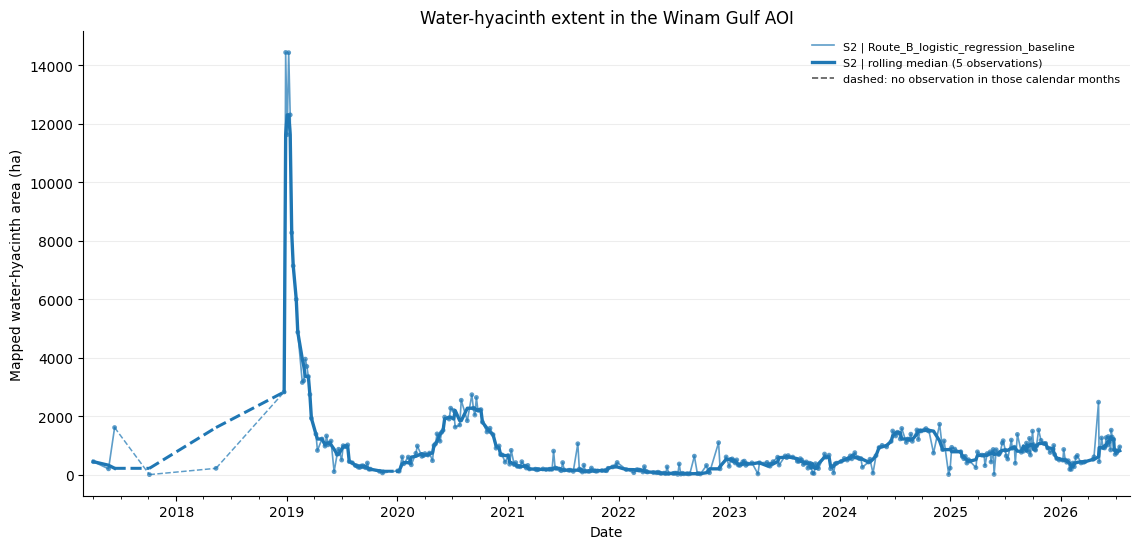

S2 | Route_B_logistic_regression_baseline: 372 classified dates in 96 calendar months; 16 further month(s) inside the record carry no observation (4 dashed stretch(es))


,first_missing_month,last_missing_month,n_months
0,2017-11,2018-04,6
1,2018-06,2018-11,6
2,2017-07,2017-09,3
3,2019-12,2019-12,1



Saved figure to:
/content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/figures/winam_rebuilt_aoi_wh_timeseries.png


In [7]:
plot_df = wh_ts.copy()

if PLOT_SENSOR is not None:
    plot_df = plot_df[plot_df["sensor"].eq(PLOT_SENSOR)]

if PLOT_KIND is not None:
    plot_df = plot_df[plot_df["kind"].eq(PLOT_KIND)]

if plot_df.empty:
    raise RuntimeError(
        "The plot filters selected no rows. "
        "Change PLOT_SENSOR / PLOT_KIND in the configuration cell."
    )

fig, ax = plt.subplots(figsize=(11.5, 5.6))

gap_reports = []

for (sensor, method), group in plot_df.groupby(["sensor", "method"], sort=True):
    group = group.sort_values("mid_date")

    label = f"{sensor} | {method}"
    line = plot_with_month_gaps(
        ax,
        group["mid_date"],
        group["wh_area_ha"],
        dash_gaps=DASH_UNOBSERVED_MONTHS,
        linewidth=1.2,
        alpha=0.72,
        label=label,
    )

    # Markers land on classified dates only, so a dashed stretch never carries
    # a point that was not measured.
    ax.scatter(
        group["mid_date"],
        group["wh_area_ha"],
        s=12,
        alpha=0.72,
        color=line.get_color(),
        edgecolors="none",
    )

    if ROLLING_MEDIAN_POINTS and ROLLING_MEDIAN_POINTS > 1:
        rolling = (
            group["wh_area_ha"]
            .rolling(
                ROLLING_MEDIAN_POINTS,
                center=True,
                min_periods=max(2, ROLLING_MEDIAN_POINTS // 2),
            )
            .median()
        )
        plot_with_month_gaps(
            ax,
            group["mid_date"],
            rolling,
            dash_gaps=DASH_UNOBSERVED_MONTHS,
            linewidth=2.4,
            color=line.get_color(),
            label=f"{sensor} | rolling median ({ROLLING_MEDIAN_POINTS} observations)",
        )

    spans = month_gap_spans(group["mid_date"])
    gap_reports.append((label, group, spans))

ax.set_title("Water-hyacinth extent in the Winam Gulf AOI")
ax.set_xlabel("Date")
ax.set_ylabel("Mapped water-hyacinth area (ha)")

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=(4, 7, 10)))

ax.grid(axis="y", alpha=0.22)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.margins(x=0.01)

# One handle explains the convention for every series, so the dashes stay out
# of the per-series legend entries.
handles, labels = ax.get_legend_handles_labels()
if DASH_UNOBSERVED_MONTHS and any(len(spans) for _, _, spans in gap_reports):
    handles.append(Line2D([], [], color="0.35", linestyle="--", linewidth=1.2))
    labels.append("dashed: no observation in those calendar months")
ax.legend(handles, labels, frameon=False, fontsize=8)

fig.tight_layout()
fig.savefig(PNG_PATH, dpi=300, bbox_inches="tight")
plt.show()

for label, group, spans in gap_reports:
    observed_months = int(group["mid_date"].dt.to_period("M").nunique())
    n_missing = int(spans["n_months"].sum())
    print(
        f"{label}: {len(group):,} classified dates in {observed_months} calendar "
        f"months; {n_missing} further month(s) inside the record carry no "
        f"observation ({len(spans)} dashed stretch(es))"
    )
    if len(spans):
        display(spans)

print("\nSaved figure to:")
print(PNG_PATH)


### Plot percentage coverage instead

The dataframe also contains `wh_coverage_pct`, calculated as WH pixels divided by all valid classified pixels for each raster. To plot that instead, replace `wh_area_ha` with `wh_coverage_pct` in the plotting cell and change the y-axis label to `Valid classified AOI occupied by WH (%)`.
